In [1]:
!pip install pandas


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# import pandas as pd
# df = pd.read_csv('city_day.csv')

In [3]:
# df.shape
# df.info()
# df.describe()
# df['City'].nunique()
# df['AQI_Bucket'].unique()

In [4]:
# pip install meteostat geopy requests

In [5]:

# import pandas as pd
# import requests
# import time

# # Load your dataset
# df = pd.read_csv('city_day.csv')
# df['Date'] = pd.to_datetime(df['Date'])

# # COMPLETE Dictionary of Coordinates for all cities in your dataset
# city_coords = {
#     'Ahmedabad': {'lat': 23.0225, 'lon': 72.5714},
#     'Aizawl': {'lat': 23.7271, 'lon': 92.7176},
#     'Amaravati': {'lat': 16.5131, 'lon': 80.5165},
#     'Amritsar': {'lat': 31.6340, 'lon': 74.8723},
#     'Bengaluru': {'lat': 12.9716, 'lon': 77.5946},
#     'Bhopal': {'lat': 23.2599, 'lon': 77.4126},
#     'Brajrajnagar': {'lat': 21.8216, 'lon': 83.9216},
#     'Chandigarh': {'lat': 30.7333, 'lon': 76.7794},
#     'Chennai': {'lat': 13.0827, 'lon': 80.2707},
#     'Coimbatore': {'lat': 11.0168, 'lon': 76.9558},
#     'Delhi': {'lat': 28.6139, 'lon': 77.2090},
#     'Ernakulam': {'lat': 9.9816, 'lon': 76.2999},
#     'Gurugram': {'lat': 28.4601, 'lon': 77.0199},
#     'Guwahati': {'lat': 26.1445, 'lon': 91.7362},
#     'Hyderabad': {'lat': 17.3850, 'lon': 78.4867},
#     'Jaipur': {'lat': 26.9124, 'lon': 75.7873},
#     'Jorapokhar': {'lat': 23.7004, 'lon': 86.4125},
#     'Kochi': {'lat': 9.9312, 'lon': 76.2673},
#     'Kolkata': {'lat': 22.5726, 'lon': 88.3639},
#     'Lucknow': {'lat': 26.8467, 'lon': 80.9462},
#     'Mumbai': {'lat': 19.0760, 'lon': 72.8777},
#     'Patna': {'lat': 25.5941, 'lon': 85.1376},
#     'Shillong': {'lat': 25.5788, 'lon': 91.8933},
#     'Talcher': {'lat': 20.9509, 'lon': 85.2163},
#     'Thiruvananthapuram': {'lat': 8.5241, 'lon': 76.9366},
#     'Visakhapatnam': {'lat': 17.6868, 'lon': 83.2185}
# }

# weather_frames = []

# # Fetch data using the complete list
# for city in df['City'].unique():
#     # Safety check in case a new city appears in future data
#     if city not in city_coords:
#         print(f"⚠️ Skipping {city}: Coordinates still missing.")
#         continue
        
#     lat = city_coords[city]['lat']
#     lon = city_coords[city]['lon']
    
#     # Get date range for this specific city
#     city_data = df[df['City'] == city]
#     start_date = city_data['Date'].min().strftime('%Y-%m-%d')
#     end_date = city_data['Date'].max().strftime('%Y-%m-%d')
    
#     print(f"Fetching data for {city}...")
    
#     try:
#         # Fetch Temperature, Humidity, and Wind Speed
#         url = f"https://archive-api.open-meteo.com/v1/archive?latitude={lat}&longitude={lon}&start_date={start_date}&end_date={end_date}&daily=temperature_2m_mean,relative_humidity_2m_mean,wind_speed_10m_max&timezone=auto"
        
#         response = requests.get(url)
        
#         if response.status_code == 200:
#             data = response.json()
            
#             # Create a temporary dataframe for the weather data
#             temp_df = pd.DataFrame({
#                 'Date': pd.to_datetime(data['daily']['time']),
#                 'City': city,
#                 'Temp_Mean': data['daily']['temperature_2m_mean'],
#                 'Humidity_Mean': data['daily']['relative_humidity_2m_mean'],
#                 'Wind_Speed_Max': data['daily']['wind_speed_10m_max']
#             })
#             weather_frames.append(temp_df)
#         else:
#             print(f"❌ Error fetching {city}: {response.status_code}")
            
#     except Exception as e:
#         print(f"❌ Exception for {city}: {e}")
    
#     # Pause briefly to respect API rate limits
#     time.sleep(1)

# # Combine and Merge
# if weather_frames:
#     all_weather_df = pd.concat(weather_frames)
    
#     # Merge with original data
#     final_df = pd.merge(df, all_weather_df, on=['City', 'Date'], how='left')
    
#     # Save to CSV
#     final_df.to_csv('city_day_with_weather_complete.csv', index=False)
#     print("\n✅ Success! All cities updated. Saved to 'city_day_with_weather_complete.csv'")
# else:
#     print("\n❌ No weather data fetched.")

In [7]:
import pandas as pd
import numpy as np
df = pd.read_csv('city_day_with_weather_complete.csv')
df_numeric = df.select_dtypes(include=np.number)

df_numeric.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Temp_Mean,Humidity_Mean,Wind_Speed_Max
0,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,20.3,67,14.8
1,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,20.4,65,15.6
2,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,19.7,70,11.4
3,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,19.8,64,13.6
4,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,19.0,53,15.2


In [8]:
df.head()

,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Temp_Mean,Humidity_Mean,Wind_Speed_Max
0,Ahmedabad,2015-01-01,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,NaN,20.3,67,14.8
1,Ahmedabad,2015-01-02,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,NaN,20.4,65,15.6
2,Ahmedabad,2015-01-03,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,NaN,19.7,70,11.4
3,Ahmedabad,2015-01-04,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,NaN,19.8,64,13.6
4,Ahmedabad,2015-01-05,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,NaN,19.0,53,15.2


In [9]:
df_numeric = df.select_dtypes(include=np.number)

df_numeric.head()

,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,Temp_Mean,Humidity_Mean,Wind_Speed_Max
0,NaN,NaN,0.92,18.22,17.15,NaN,0.92,27.64,133.36,0.00,0.02,0.00,NaN,20.3,67,14.8
1,NaN,NaN,0.97,15.69,16.46,NaN,0.97,24.55,34.06,3.68,5.50,3.77,NaN,20.4,65,15.6
2,NaN,NaN,17.40,19.30,29.70,NaN,17.40,29.07,30.70,6.80,16.40,2.25,NaN,19.7,70,11.4
3,NaN,NaN,1.70,18.48,17.97,NaN,1.70,18.59,36.08,4.43,10.14,1.00,NaN,19.8,64,13.6
4,NaN,NaN,22.10,21.42,37.76,NaN,22.10,39.33,39.31,7.01,18.89,2.78,NaN,19.0,53,15.2


In [10]:
corr_matrix = df_numeric.corr()
print(corr_matrix)

                   PM2.5      PM10        NO       NO2       NOx       NH3  \
PM2.5           1.000000  0.846498  0.433491  0.350709  0.436792  0.275086   
PM10            0.846498  1.000000  0.502349  0.464380  0.527768  0.376816   
NO              0.433491  0.502349  1.000000  0.478070  0.794890  0.185621   
NO2             0.350709  0.464380  0.478070  1.000000  0.627627  0.234938   
NOx             0.436792  0.527768  0.794890  0.627627  1.000000  0.166224   
NH3             0.275086  0.376816  0.185621  0.234938  0.166224  1.000000   
CO              0.089912  0.112588  0.212607  0.356521  0.226992  0.104891   
SO2             0.132325  0.256974  0.170322  0.392233  0.238397 -0.038998   
O3              0.161238  0.244919  0.014580  0.293349  0.093170  0.094972   
Benzene         0.023911  0.022265  0.035771  0.025260  0.039121 -0.015650   
Toluene         0.117080  0.169335  0.150857  0.273926  0.189386  0.013227   
Xylene          0.114579  0.081700  0.094237  0.171701  0.087398

In [11]:
corr_matrix = df_numeric.corr()
corr_matrix['AQI'].sort_values(ascending=False)
corr_target = corr_matrix['AQI'].abs()

selected_features = corr_target[corr_target > 0.3].index
selected_features

Index(['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'AQI'], dtype='object')

In [12]:
!pip install matplotlib seaborn


[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


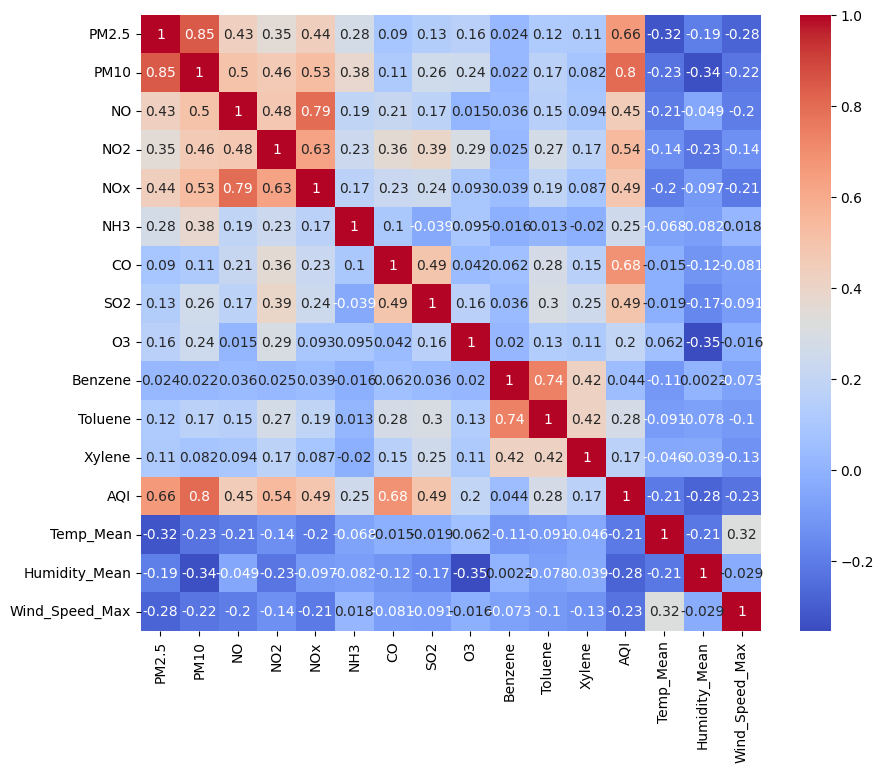

In [13]:
X = df_numeric[selected_features]
y = df_numeric['AQI']
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, cmap='coolwarm', annot=True)
plt.show()

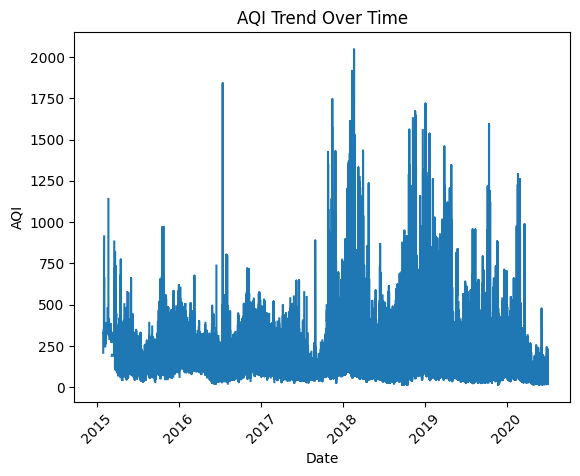

In [14]:
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date (very important for time series)
df = df.sort_values('Date')
plt.figure()
plt.plot(df['Date'], df['AQI'])
plt.title("AQI Trend Over Time")
plt.xlabel("Date")
plt.ylabel("AQI")
plt.xticks(rotation=45)
plt.show()

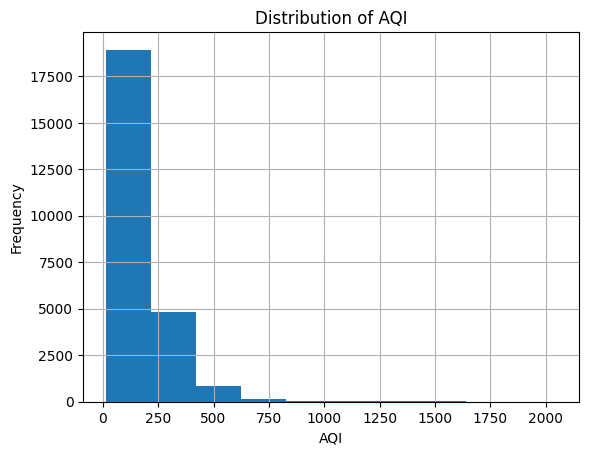

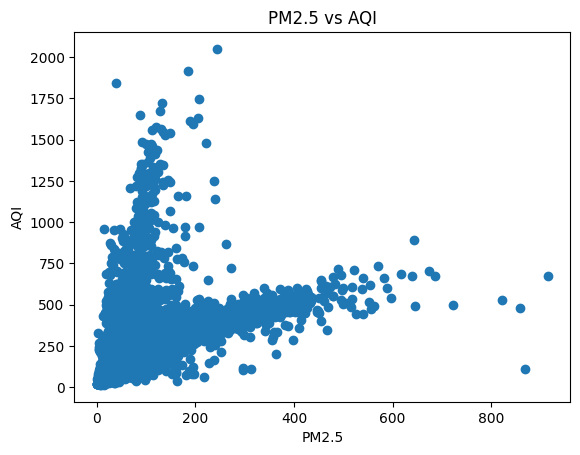

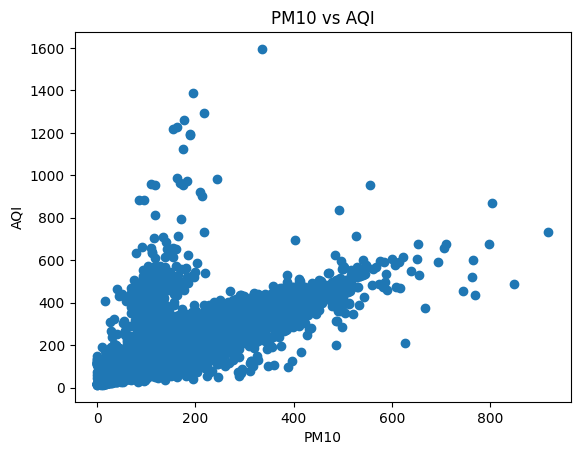

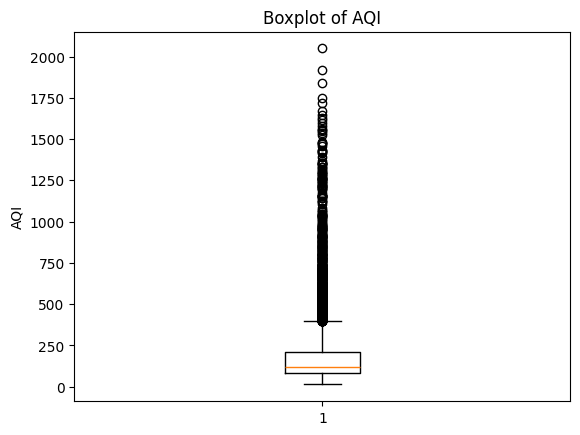

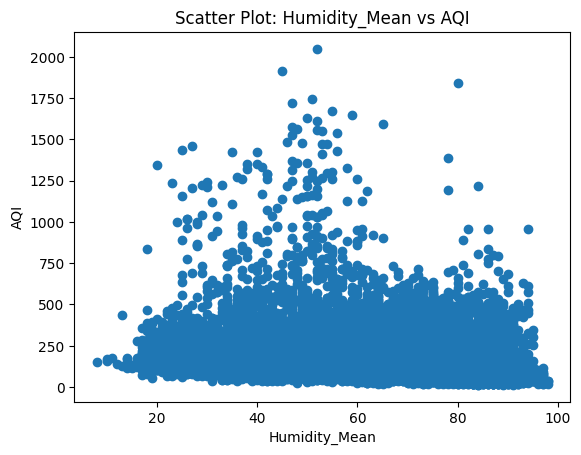

<Figure size 640x480 with 0 Axes>

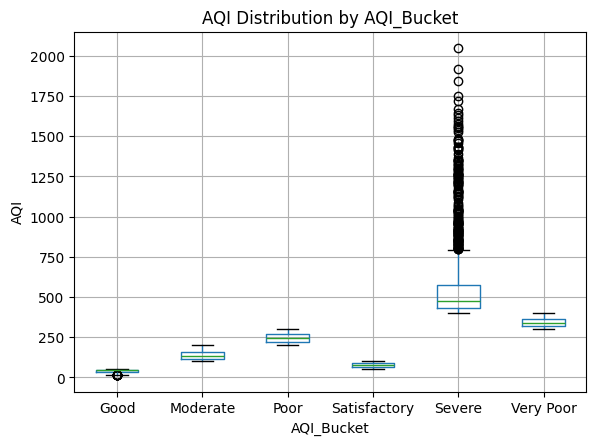

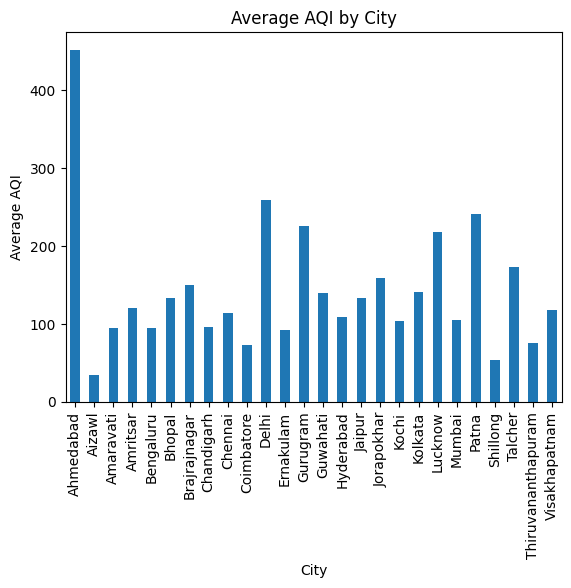

In [15]:
# 1. Histogram - AQI
plt.figure()
df['AQI'].dropna().hist()
plt.title("Distribution of AQI")
plt.xlabel("AQI")
plt.ylabel("Frequency")
plt.show()


# 2. Scatter Plot - PM2.5 vs AQI
plt.figure()
plt.scatter(df['PM2.5'], df['AQI'])
plt.title("PM2.5 vs AQI")
plt.xlabel("PM2.5")
plt.ylabel("AQI")
plt.show()


# 3. Scatter Plot - PM10 vs AQI
plt.figure()
plt.scatter(df['PM10'], df['AQI'])
plt.title("PM10 vs AQI")
plt.xlabel("PM10")
plt.ylabel("AQI")
plt.show()


# 4. Boxplot - AQI (Outlier Detection)
plt.figure()
plt.boxplot(df['AQI'].dropna())
plt.title("Boxplot of AQI")
plt.ylabel("AQI")
plt.show()

plt.figure()
plt.scatter(df['Humidity_Mean'], df['AQI'])
plt.title("Scatter Plot: Humidity_Mean vs AQI")
plt.xlabel("Humidity_Mean")
plt.ylabel("AQI")
plt.show()

plt.figure()
df.boxplot(column='AQI', by='AQI_Bucket')
plt.title("AQI Distribution by AQI_Bucket")
plt.suptitle("")  # removes automatic subtitle
plt.xlabel("AQI_Bucket")
plt.ylabel("AQI")
plt.show()


# Bar Plot: Average AQI by City
# ----------------------------
plt.figure()
df.groupby('City')['AQI'].mean().plot(kind='bar')
plt.title("Average AQI by City")
plt.xlabel("City")
plt.ylabel("Average AQI")
plt.show()

In [16]:
df = pd.read_csv('city_day_with_weather_complete.csv')

df = df.dropna(subset=['AQI', 'AQI_Bucket'])

columns_to_drop = [
    'AQI_Bucket',
    'NH3',
    'O3',
    'Benzene',
    'Toluene',
    'Xylene',
]

df = df.drop(columns=columns_to_drop)

In [17]:
# 1. Remove all rows where City is 'Lucknow'
df = df[df['City'] != 'Lucknow']
df.isnull().sum()

City                 0
Date                 0
PM2.5              676
PM10              5193
NO                 385
NO2                389
NOx               1552
CO                 437
SO2                604
AQI                  0
Temp_Mean            0
Humidity_Mean        0
Wind_Speed_Max       0
dtype: int64

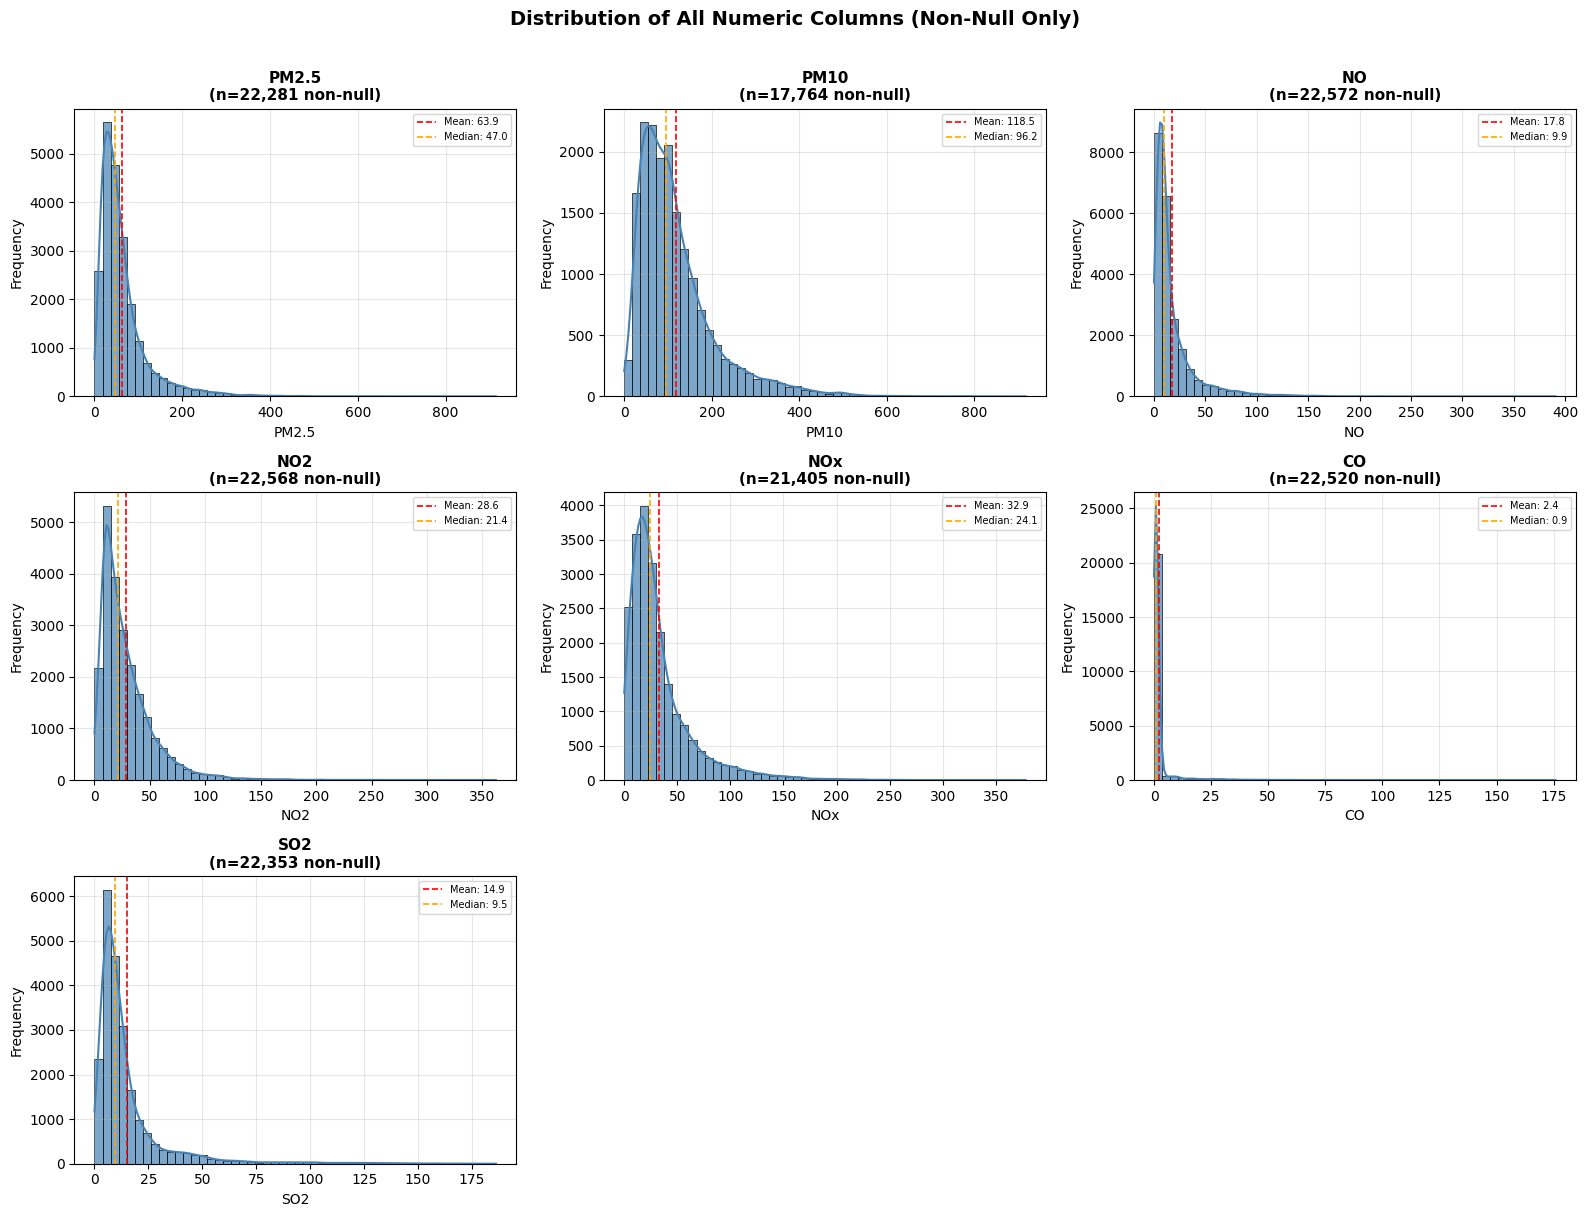

Saved: distributions.png


In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns with non-null values
numeric_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2']

ncols = 3
nrows = int(np.ceil(len(numeric_cols) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(16, nrows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    data = df[col].dropna()  # only non-null values
    
    sns.histplot(data, ax=ax, kde=True, color='steelblue', bins=50, alpha=0.7)
    
    ax.set_title(f"{col}\n(n={len(data):,} non-null)", fontsize=11, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.2, label=f'Mean: {data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle='--', linewidth=1.2, label=f'Median: {data.median():.1f}')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

# Hide unused subplots
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of All Numeric Columns (Non-Null Only)", 
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig("distributions.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: distributions.png")

In [19]:
# Columns with nulls to fill
cols_to_fill = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2']

# Fill nulls with median per city (better than global median)
for col in cols_to_fill:
    df[col] = df.groupby('City')[col].transform(
        lambda x: x.fillna(x.median())
    )

# Check if any nulls remain (edge case: entire city has no values)
remaining = df[cols_to_fill].isnull().sum()
print("Nulls remaining after city-level fill:")
print(remaining)

# If any still remain, fill with global median as fallback
for col in cols_to_fill:
    if df[col].isnull().sum() > 0:
        df[col].fillna(df[col].median(), inplace=True)

print("\nFinal null check:")
print(df[cols_to_fill].isnull().sum())

Nulls remaining after city-level fill:
PM2.5      0
PM10       0
NO         0
NO2        0
NOx      771
CO         0
SO2        0
dtype: int64

Final null check:
PM2.5    0
PM10     0
NO       0
NO2      0
NOx      0
CO       0
SO2      0
dtype: int64


c:\Users\prasi\.pyenv\pyenv-win\versions\3.10.11\lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
C:\Users\prasi\AppData\Local\Temp\ipykernel_11560\168478676.py:18: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


In [20]:
#df.to_csv('city_day_clean.csv', index=False)

In [ ]:
# from sklearn.experimental import enable_iterative_imputer
# from sklearn.impute import IterativeImputer
# from sklearn.ensemble import RandomForestRegressor

# # 1. Load the dataset (after dropping NaN targets)
# #df = pd.read_csv('city_day_clean.csv')
# df['Date'] = pd.to_datetime(df['Date'])

# # 2. Define a STRICT, safe interpolation function
# def safe_interpolate(group):
#     numeric_cols = group.select_dtypes(include=['number']).columns
    
#     # limit=7: Only draw a line if the gap is 7 days or less
#     # limit_area='inside': NEVER backfill or forward-fill into the unknown edges
#     group[numeric_cols] = group[numeric_cols].interpolate(
#         method='linear', 
#         limit=7, 
#         limit_area='inside'
#     )
#     return group

# # Apply safe interpolation
# df_interpolated = df.groupby('City', group_keys=False).apply(safe_interpolate)

# # 3. Use Machine Learning to fill the remaining large gaps (Multivariate Imputation)
# # This will use the correlations between PM2.5, NO2, Temp, etc., to guess missing PM10
# print(f"Missing before Iterative Imputer: \n{df_interpolated.isnull().sum()}")

# # Isolate numeric columns for the imputer
# numeric_df = df_interpolated.select_dtypes(include=['number'])
# numeric_cols = numeric_df.columns

# # Initialize Iterative Imputer (using a fast estimator like Ridge or small Random Forest)
# imputer = IterativeImputer(
#     estimator=RandomForestRegressor(n_estimators=10, random_state=42, n_jobs=-1),
#     max_iter=10,
#     random_state=42
# )

# # Fit and transform
# print("Running Iterative Imputer (this may take a minute)...")
# imputed_data = imputer.fit_transform(numeric_df)

# # Put the imputed data back into the dataframe
# df_interpolated[numeric_cols] = imputed_data

# print(f"Missing after Iterative Imputer: \n{df_interpolated.isnull().sum()}")

# # Save
# df_interpolated.to_csv('city_day_interpolated_fixed.csv', index=False)

In [22]:
pip install xgboost lightgbm tensorflow scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.0.1
[notice] To update, run: c:\Users\prasi\.pyenv\pyenv-win\versions\3.10.11\python.exe -m pip install --upgrade pip


In [23]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_squared_error

In [24]:
df.isnull().sum()

City              0
Date              0
PM2.5             0
PM10              0
NO                0
NO2               0
NOx               0
CO                0
SO2               0
AQI               0
Temp_Mean         0
Humidity_Mean     0
Wind_Speed_Max    0
dtype: int64

In [25]:
df = df.sort_values(by=['City', 'Date'])

# All pollutant columns to create lag/roll for
poll_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'AQI']

for col in poll_cols:
    grp = df.groupby('City')[col]
    
    # Lag features — what was the value 1, 3, 7 days ago?
    df[f'{col}_lag1'] = grp.shift(1)
    df[f'{col}_lag3'] = grp.shift(3)
    df[f'{col}_lag7'] = grp.shift(7)
    
    # Rolling mean — average trend over past 7 and 30 days
    df[f'{col}_roll7_mean']  = grp.shift(1).transform(
        lambda x: x.rolling(7,  min_periods=1).mean())
    df[f'{col}_roll30_mean'] = grp.shift(1).transform(
        lambda x: x.rolling(30, min_periods=1).mean())
    
    # Rolling std — how volatile has it been?
    df[f'{col}_roll7_std']   = grp.shift(1).transform(
        lambda x: x.rolling(7,  min_periods=1).std())

df.dropna(inplace=True)

In [26]:
y = df['AQI']

# Features
X = df.drop(columns=['AQI'])

In [27]:
X = X.copy()

X['Date'] = pd.to_datetime(X['Date'], errors='coerce')

X['year'] = X['Date'].dt.year
X['month'] = X['Date'].dt.month
X['day'] = X['Date'].dt.day
X['day_of_week'] = X['Date'].dt.dayofweek

X = X.drop(columns=['Date'])

df = df.sort_values(by=['City', 'Date'])

split_index = int(0.8 * len(X))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set size: {len(X_train)}")
print(f"Testing set size: {len(X_test)}")

Training set size: 18225
Testing set size: 4557


In [28]:
categorical_features = ['City']
numeric_features = X.drop(columns=['City']).columns

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

In [29]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42))
])

In [31]:
from xgboost import XGBRegressor

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1))
])

In [32]:
# from lightgbm import LGBMRegressor

# lgbm_model = Pipeline([
#     ('preprocessor', preprocessor),
#     ('model', LGBMRegressor(n_estimators=100))
# ])

In [33]:
import numpy as np
from sklearn.preprocessing import MinMaxScaler

In [34]:
models = {
    "Ridge Regression": ridge_model,
    "Random Forest": rf_model,
    "XGBoost": xgb_model
}

In [ ]:
import numpy as np
from sklearn.metrics import mean_squared_error, r2_score

results = []

# Sklearn Models
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)

    results.append([name, mse, rmse, r2])


# Convert to DataFrame (BEST for report)
import pandas as pd

results_df = pd.DataFrame(results, columns=["Model", "MSE", "RMSE", "R2"])

print(results_df)

              Model         MSE       RMSE        R2
0  Ridge Regression  649.619823  25.487641  0.946116
1     Random Forest  481.039500  21.932613  0.960100
2           XGBoost  485.871696  22.042498  0.959699


In [36]:
print("Features used in X:")
print(X.columns.tolist())
print(f"\nTotal features: {X.shape[1]}")

Features used in X:
['City', 'PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'Temp_Mean', 'Humidity_Mean', 'Wind_Speed_Max', 'PM2.5_lag1', 'PM2.5_lag3', 'PM2.5_lag7', 'PM2.5_roll7_mean', 'PM2.5_roll30_mean', 'PM2.5_roll7_std', 'PM10_lag1', 'PM10_lag3', 'PM10_lag7', 'PM10_roll7_mean', 'PM10_roll30_mean', 'PM10_roll7_std', 'NO_lag1', 'NO_lag3', 'NO_lag7', 'NO_roll7_mean', 'NO_roll30_mean', 'NO_roll7_std', 'NO2_lag1', 'NO2_lag3', 'NO2_lag7', 'NO2_roll7_mean', 'NO2_roll30_mean', 'NO2_roll7_std', 'NOx_lag1', 'NOx_lag3', 'NOx_lag7', 'NOx_roll7_mean', 'NOx_roll30_mean', 'NOx_roll7_std', 'CO_lag1', 'CO_lag3', 'CO_lag7', 'CO_roll7_mean', 'CO_roll30_mean', 'CO_roll7_std', 'SO2_lag1', 'SO2_lag3', 'SO2_lag7', 'SO2_roll7_mean', 'SO2_roll30_mean', 'SO2_roll7_std', 'AQI_lag1', 'AQI_lag3', 'AQI_lag7', 'AQI_roll7_mean', 'AQI_roll30_mean', 'AQI_roll7_std', 'year', 'month', 'day', 'day_of_week']

Total features: 63


In [37]:
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'model__n_estimators':     [300, 500],
#     'model__max_depth':        [15, 20, None],
#     'model__min_samples_split':[2, 5],
#     'model__min_samples_leaf': [1, 2],
#     'model__max_features':     [0.6, 0.8, 'sqrt'],
# }

# grid_search = GridSearchCV(
#     rf_model,
#     param_grid,
#     cv=3,
#     scoring='neg_mean_squared_error',
#     n_jobs=-1,
#     verbose=1
# )
# grid_search.fit(X_train, y_train)

# print("Best params:", grid_search.best_params_)
# y_pred = grid_search.predict(X_test)
# print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
# print("R²:  ", r2_score(y_test, y_pred))

STEP 1 — Loading Data
  Raw shape: (29531, 19)
  Clean shape: (22957, 13)
  Cities: ['Ahmedabad', 'Aizawl', 'Amaravati', 'Amritsar', 'Bengaluru', 'Bhopal', 'Brajrajnagar', 'Chandigarh', 'Chennai', 'Coimbatore', 'Delhi', 'Ernakulam', 'Gurugram', 'Guwahati', 'Hyderabad', 'Jaipur', 'Jorapokhar', 'Kochi', 'Kolkata', 'Mumbai', 'Patna', 'Shillong', 'Talcher', 'Thiruvananthapuram', 'Visakhapatnam']
  Date range: 2015-01-01 → 2020-07-01

STEP 2 — Filling Null Values
  Nulls before fill:
PM2.5     676
PM10     5193
NO        385
NO2       389
NOx      1552
CO        437
SO2       604

  Nulls after fill:
PM2.5    0
PM10     0
NO       0
NO2      0
NOx      0
CO       0
SO2      0

STEP 3 — Sorting by City & Date
  Done.

STEP 4 — Feature Engineering
  Shape after lag features: (22782, 61)

STEP 5 — Defining Features & Target
  Total features : 65
  Total samples  : 22782

  Feature list:
      1. City
      2. PM2.5
      3. PM10
      4. NO
      5. NO2
      6. NOx
      7. CO
      8. SO2
  

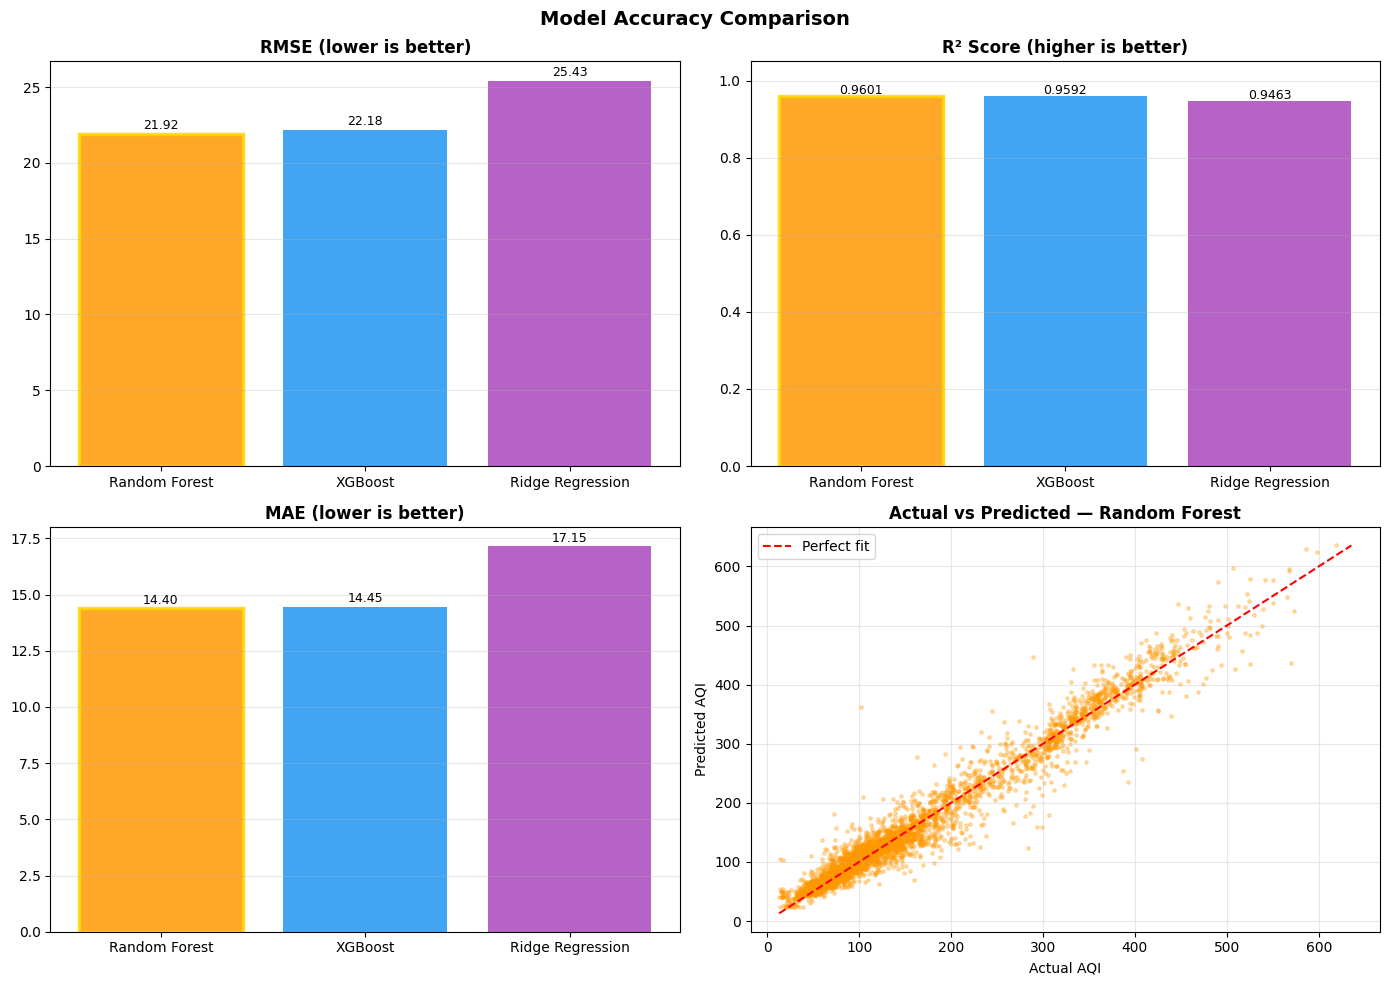

  Saved: model_comparison_plot.png


In [38]:
"""
=============================================================
  AQI PREDICTION — FULL PIPELINE
  Load → Clean → Feature Engineering → Train → Compare
=============================================================
"""

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from xgboost import XGBRegressor

# ══════════════════════════════════════════════════════════
# STEP 1 — LOAD DATA (only once)
# ══════════════════════════════════════════════════════════
print("=" * 60)
print("STEP 1 — Loading Data")
print("=" * 60)

df = pd.read_csv('city_day_with_weather_complete.csv')
print(f"  Raw shape: {df.shape}")

# Drop rows where target is missing
df = df.dropna(subset=['AQI'])

# Drop unnecessary columns
cols_to_drop = [c for c in ['AQI_Bucket', 'NH3', 'O3', 'Benzene',
                             'Toluene', 'Xylene'] if c in df.columns]
df = df.drop(columns=cols_to_drop)

# Remove Lucknow (too many missing values)
df = df[df['City'] != 'Lucknow']

df['Date'] = pd.to_datetime(df['Date'])
print(f"  Clean shape: {df.shape}")
print(f"  Cities: {sorted(df['City'].unique())}")
print(f"  Date range: {df['Date'].min().date()} → {df['Date'].max().date()}")

# ══════════════════════════════════════════════════════════
# STEP 2 — FILL NULLS WITH CITY-LEVEL MEDIAN
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 2 — Filling Null Values")
print("=" * 60)

cols_to_fill = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2']
cols_to_fill = [c for c in cols_to_fill if c in df.columns]

print("  Nulls before fill:")
print(df[cols_to_fill].isnull().sum().to_string())

for col in cols_to_fill:
    # City-level median first
    df[col] = df.groupby('City')[col].transform(
        lambda x: x.fillna(x.median())
    )
    # Global median fallback
    if df[col].isnull().sum() > 0:
        df[col] = df[col].fillna(df[col].median())

print("\n  Nulls after fill:")
print(df[cols_to_fill].isnull().sum().to_string())

# ══════════════════════════════════════════════════════════
# STEP 3 — SORT (must happen before lag features)
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 3 — Sorting by City & Date")
print("=" * 60)

df = df.sort_values(by=['City', 'Date']).reset_index(drop=True)
print("  Done.")

# ══════════════════════════════════════════════════════════
# STEP 4 — FEATURE ENGINEERING
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 4 — Feature Engineering")
print("=" * 60)

# ── Lag & rolling features ─────────────────────────────────
poll_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'CO', 'SO2', 'AQI']
poll_cols = [c for c in poll_cols if c in df.columns]

for col in poll_cols:
    grp = df.groupby('City')[col]

    # Lag features
    df[f'{col}_lag1'] = grp.shift(1)
    df[f'{col}_lag3'] = grp.shift(3)
    df[f'{col}_lag7'] = grp.shift(7)

    # Rolling mean
    df[f'{col}_roll7_mean']  = grp.shift(1).transform(
        lambda x: x.rolling(7,  min_periods=1).mean())
    df[f'{col}_roll30_mean'] = grp.shift(1).transform(
        lambda x: x.rolling(30, min_periods=1).mean())

    # Rolling std (volatility)
    df[f'{col}_roll7_std'] = grp.shift(1).transform(
        lambda x: x.rolling(7, min_periods=1).std())

df.dropna(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"  Shape after lag features: {df.shape}")

# ── Date parts ─────────────────────────────────────────────
df['year']       = df['Date'].dt.year
df['month']      = df['Date'].dt.month
df['day']        = df['Date'].dt.day
df['day_of_week']= df['Date'].dt.dayofweek

# ── Cyclical encoding for month ───────────────────────────
df['month_sin']  = np.sin(2 * np.pi * df['month'] / 12)
df['month_cos']  = np.cos(2 * np.pi * df['month'] / 12)

# ══════════════════════════════════════════════════════════
# STEP 5 — DEFINE X AND y
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 5 — Defining Features & Target")
print("=" * 60)

y = df['AQI']
X = df.drop(columns=['AQI', 'Date']).copy()

print(f"  Total features : {X.shape[1]}")
print(f"  Total samples  : {X.shape[0]}")
print("\n  Feature list:")
for i, col in enumerate(X.columns, 1):
    print(f"    {i:3}. {col}")

# ══════════════════════════════════════════════════════════
# STEP 6 — TRAIN / TEST SPLIT (time-based)
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 6 — Train/Test Split (80/20 time-based)")
print("=" * 60)

split_index = int(0.8 * len(X))
X_train = X.iloc[:split_index]
X_test  = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test  = y.iloc[split_index:]

print(f"  Train size : {len(X_train):,}")
print(f"  Test size  : {len(X_test):,}")

# ══════════════════════════════════════════════════════════
# STEP 7 — PREPROCESSOR
# ══════════════════════════════════════════════════════════
categorical_features = ['City']
numeric_features     = [c for c in X.columns if c != 'City']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(),                      numeric_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])

# ══════════════════════════════════════════════════════════
# STEP 8 — TRAIN ALL MODELS
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 8 — Training Models")
print("=" * 60)

ridge_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', Ridge(alpha=1.0))
])

rf_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1))
])

xgb_model = Pipeline([
    ('preprocessor', preprocessor),
    ('model', XGBRegressor(n_estimators=100, learning_rate=0.1,
                           random_state=42, n_jobs=-1))
])

models = {
    "Ridge Regression": ridge_model,
    "Random Forest":    rf_model,
    "XGBoost":          xgb_model,
}

results  = []
all_preds = {}

for name, model in models.items():
    print(f"  Training {name} ...", end=" ", flush=True)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    all_preds[name] = y_pred

    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_test, y_pred)
    r2   = r2_score(y_test, y_pred)
    mape = np.mean(np.abs((y_test - y_pred) / (y_test + 1e-5))) * 100

    results.append([name, round(mse,4), round(rmse,4),
                    round(mae,4), round(r2,6), round(mape,4)])
    print("done")

# ══════════════════════════════════════════════════════════
# STEP 9 — COMPARE ACCURACY
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 9 — Model Comparison")
print("=" * 60)

results_df = pd.DataFrame(
    results, columns=["Model", "MSE", "RMSE", "MAE", "R2", "MAPE%"]
).sort_values("RMSE").reset_index(drop=True)

print(results_df.to_string(index=False))
results_df.to_csv("model_comparison.csv", index=False)
print("\n  Saved: model_comparison.csv")

best_model_name = results_df.iloc[0]["Model"]
print(f"\n  🏆 Best model: {best_model_name}")

# ══════════════════════════════════════════════════════════
# STEP 10 — ACCURACY PLOTS
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("STEP 10 — Plotting Accuracy")
print("=" * 60)

MODEL_COLORS = {
    "Ridge Regression": "#AB47BC",
    "Random Forest":    "#FF9800",
    "XGBoost":          "#2196F3",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Model Accuracy Comparison", fontsize=14, fontweight="bold")

model_names = results_df["Model"].tolist()
colors      = [MODEL_COLORS[m] for m in model_names]

# RMSE
ax = axes[0, 0]
bars = ax.bar(model_names, results_df["RMSE"], color=colors, alpha=0.85)
ax.set_title("RMSE (lower is better)", fontweight="bold")
for bar, val in zip(bars, results_df["RMSE"]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.3, f"{val:.2f}", ha="center", fontsize=9)
bars[0].set_edgecolor("gold"); bars[0].set_linewidth(2.5)
ax.grid(axis="y", alpha=0.3)

# R²
ax = axes[0, 1]
bars = ax.bar(model_names, results_df["R2"], color=colors, alpha=0.85)
ax.set_title("R² Score (higher is better)", fontweight="bold")
ax.set_ylim(0, 1.05)
for bar, val in zip(bars, results_df["R2"]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.005, f"{val:.4f}", ha="center", fontsize=9)
bars[0].set_edgecolor("gold"); bars[0].set_linewidth(2.5)
ax.grid(axis="y", alpha=0.3)

# MAE
ax = axes[1, 0]
bars = ax.bar(model_names, results_df["MAE"], color=colors, alpha=0.85)
ax.set_title("MAE (lower is better)", fontweight="bold")
for bar, val in zip(bars, results_df["MAE"]):
    ax.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()+0.2, f"{val:.2f}", ha="center", fontsize=9)
bars[0].set_edgecolor("gold"); bars[0].set_linewidth(2.5)
ax.grid(axis="y", alpha=0.3)

# Actual vs Predicted (best model)
ax = axes[1, 1]
bp = all_preds[best_model_name]
ax.scatter(y_test, bp, alpha=0.3, s=6, color=MODEL_COLORS[best_model_name])
lims = [min(y_test.min(), bp.min()), max(y_test.max(), bp.max())]
ax.plot(lims, lims, "r--", linewidth=1.5, label="Perfect fit")
ax.set_xlabel("Actual AQI"); ax.set_ylabel("Predicted AQI")
ax.set_title(f"Actual vs Predicted — {best_model_name}", fontweight="bold")
ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("model_comparison_plot.png", dpi=150, bbox_inches="tight")
plt.show()
print("  Saved: model_comparison_plot.png")



In [39]:
# ══════════════════════════════════════════════════════════
# STEP 8.5 — K-FOLD CROSS VALIDATION (evaluate all models)
# ══════════════════════════════════════════════════════════
from sklearn.model_selection import KFold, cross_validate
from sklearn.model_selection import TimeSeriesSplit

print("\n" + "=" * 60)
print("STEP 8.5 — K-Fold Cross Validation (k=5)")
print("=" * 60)

tscv = TimeSeriesSplit(n_splits=5)

cv_results = []

for name, model in models.items():
    print(f"  Running K-Fold on {name} ...", end=" ", flush=True)

    scores = cross_validate(
        model, X_train, y_train,
        cv=tscv,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae':  'neg_mean_absolute_error',
            'r2':   'r2'
        },
        n_jobs=-1
    )

    cv_results.append({
        "Model":       name,
        "CV_RMSE_mean": round(-scores['test_rmse'].mean(), 4),
        "CV_RMSE_std":  round( scores['test_rmse'].std(),  4),
        "CV_MAE_mean":  round(-scores['test_mae'].mean(),  4),
        "CV_R2_mean":   round( scores['test_r2'].mean(),   6),
    })
    print("done")

cv_df = pd.DataFrame(cv_results).sort_values("CV_RMSE_mean").reset_index(drop=True)

print("\n  K-Fold CV Results:")
print(cv_df.to_string(index=False))
cv_df.to_csv("kfold_cv_results.csv", index=False)
print("\n  Saved: kfold_cv_results.csv")


STEP 8.5 — K-Fold Cross Validation (k=5)
  Running K-Fold on Ridge Regression ... done
  Running K-Fold on Random Forest ... done
  Running K-Fold on XGBoost ... done

  K-Fold CV Results:
           Model  CV_RMSE_mean  CV_RMSE_std  CV_MAE_mean  CV_R2_mean
Ridge Regression       33.3344       7.1206      21.2022    0.805088
         XGBoost       33.5324       8.6186      18.5569    0.798002
   Random Forest       34.4813       7.0812      18.9271    0.791215

  Saved: kfold_cv_results.csv


In [40]:
# ══════════════════════════════════════════════════════════
# STEP 11 — GRIDSEARCHCV ON BEST MODEL
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print(f"STEP 11 — GridSearchCV on {best_model_name}")
print("=" * 60)

if best_model_name == "Random Forest":
    param_grid = {
        'model__n_estimators':      [300, 500],
        'model__max_depth':         [15, 20, None],
        'model__min_samples_split': [2, 5],
        'model__min_samples_leaf':  [1, 2],
        'model__max_features':      [0.6, 0.8, 'sqrt'],
    }
    best_pipeline = rf_model

elif best_model_name == "XGBoost":
    param_grid = {
        'model__n_estimators':     [300, 500],
        'model__max_depth':        [5, 7, 9],
        'model__learning_rate':    [0.01, 0.05, 0.1],
        'model__subsample':        [0.8, 1.0],
        'model__colsample_bytree': [0.8, 1.0],
    }
    best_pipeline = xgb_model

else:  # Ridge
    param_grid   = {'model__alpha': [0.1, 1.0, 10.0, 100.0]}
    best_pipeline = ridge_model

grid_search = GridSearchCV(
    best_pipeline,
    param_grid,
    cv=tscv,
    scoring='neg_mean_squared_error',
    n_jobs=-1,
    verbose=1
)

print(f"  Running GridSearchCV (this may take a few minutes)...")
grid_search.fit(X_train, y_train)

print(f"\n  Best params: {grid_search.best_params_}")

before_mse = results_df.iloc[0]['MSE']
y_pred_tuned = grid_search.predict(X_test)
tuned_mse = mean_squared_error(y_test, y_pred_tuned)
tuned_rmse   = np.sqrt(mean_squared_error(y_test, y_pred_tuned))
tuned_r2     = r2_score(y_test, y_pred_tuned)
tuned_mae    = mean_absolute_error(y_test, y_pred_tuned)

print(f"\n  Before tuning → MSE: {before_mse:.4f}")
print(f"  MSE  (after tuning) : {tuned_mse:.4f}")
print(f"\n  Before tuning → RMSE: {results_df.iloc[0]['RMSE']:.4f}  R²: {results_df.iloc[0]['R2']:.6f}")
print(f"  After  tuning → RMSE: {tuned_rmse:.4f}  R²: {tuned_r2:.6f}")
print(f"  MAE after tuning: {tuned_mae:.4f}")

# ══════════════════════════════════════════════════════════
# STEP 12 — FINAL SUMMARY
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)
print(f"  Best model          : {best_model_name}")
print(f"  RMSE (after tuning) : {tuned_rmse:.4f}")
print(f"  MAE  (after tuning) : {tuned_mae:.4f}")
print(f"  R²   (after tuning) : {tuned_r2:.6f}")
print("\n  Output files:")
print("    • model_comparison.csv")
print("    • model_comparison_plot.png")
print("=" * 60)


STEP 11 — GridSearchCV on Random Forest
  Running GridSearchCV (this may take a few minutes)...
Fitting 5 folds for each of 72 candidates, totalling 360 fits


KeyboardInterrupt: 